# 43 â€” Custom Objective Functions for LGBM: Focal Loss and Cliff-Aware MSE

Standard LGBM uses MSE which treats all compounds equally. The test set is enriched for
analog-expansion actives, so we need the model to excel at the active / cliff region.

**Four custom objectives compared:**

| Objective | Key idea |
|---|---|
| `focal_mse` | MSE Ã— (\|residual\| + 1)^Î³ â€” focuses on hard (high-residual) examples |
| `cliff_weighted_mse` | Higher penalty for pEC50 â‰¥ 5.5 and cliff members |
| `huber_asymmetric` | Huber loss with larger penalty for under-predicting actives |
| `quantile_aware` | MSE + 90th-percentile quantile regression mixture |

All return `(grad, hess)` for LGBM's custom objective API.

In [1]:
import sys, os, warnings
os.environ["PYTHONIOENCODING"] = "utf-8"
try:
    sys.stdout.reconfigure(encoding="utf-8")
except AttributeError:
    pass
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from pxr.data import load_train, load_test
from pxr.featurize import combined, impute
from pxr.eval import rae, scaffold_kfold_indices, compute_metrics
from pxr.chem import bemis_murcko
from pxr.paths import DATA_PROCESSED, SUBMISSIONS

LGBM_BASE_PARAMS = dict(
    n_estimators=1000, num_leaves=64, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    min_child_samples=10, n_jobs=4, verbose=-1
)

SEED = 42
print('Setup complete')

Setup complete


## 1. Load data + cliff labels

In [2]:
tr = load_train()
te = load_test()
print(f'Train: {len(tr):,}  Test: {len(te):,}')

print('Featurizing...')
X_tr = impute(combined(tr['smiles'].tolist()))
X_te = impute(combined(te['smiles'].tolist()))
y_tr = tr['pec50'].values.astype(np.float64)  # float64 for gradient stability

# Try to load cliff labels for cliff_weighted_mse objective
cliff_role_arr = np.zeros(len(tr), dtype=np.int8)
cliff_path = DATA_PROCESSED / 'cliff_labels.parquet'
if cliff_path.exists():
    try:
        cliff_df = pd.read_parquet(cliff_path)
        if 'smiles' in cliff_df.columns:
            tmp = tr.merge(cliff_df[['smiles', 'cliff_role']], on='smiles', how='left')
            cliff_role_arr = tmp['cliff_role'].fillna(0).astype(np.int8).values
        elif len(cliff_df) == len(tr):
            cliff_role_arr = cliff_df['cliff_role'].fillna(0).astype(np.int8).values
        print(f'Cliff labels loaded: {np.unique(cliff_role_arr, return_counts=True)}')
    except Exception as e:
        print(f'Could not load cliff labels: {e}. cliff_weighted_mse will use pEC50 only.')
else:
    print('cliff_labels.parquet not found. cliff_weighted_mse will use pEC50 threshold only.')

scaffolds = tr['smiles'].map(bemis_murcko).tolist()
splits = scaffold_kfold_indices(scaffolds, n_splits=5, seed=SEED)
active_mask = y_tr >= 5.5
print(f'Active compounds (pEC50 >= 5.5): {active_mask.sum()} ({100*active_mask.mean():.1f}%)')

Train: 4,139  Test: 513
Featurizing...


Cliff labels loaded: (array([-1,  0,  1], dtype=int8), array([ 115, 3891,  133]))


Active compounds (pEC50 >= 5.5): 380 (9.2%)


## 2. Custom LGBM objective functions

In [3]:
# â”€â”€ 1. Focal MSE â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Standard MSE multiplied by (|residual| + 1)^gamma.
# Gamma=2: compounds with large residuals get higher gradient magnitude.
def make_focal_mse(gamma=2.0):
    def focal_mse(y_pred, train_data):
        """Focal MSE: grad = 2*(y_pred-y_true) * (|r|+1)^gamma."""
        y_true = train_data.get_label()
        r = y_pred - y_true
        focus = (np.abs(r) + 1.0) ** gamma
        grad = 2.0 * r * focus
        # Hessian via chain rule: approximate as constant focus for stability
        hess = 2.0 * focus
        return grad.astype(np.float32), hess.astype(np.float32)
    focal_mse.__name__ = f'focal_mse_g{gamma}'
    return focal_mse

focal_mse_obj = make_focal_mse(gamma=2.0)


# â”€â”€ 2. Cliff-weighted MSE â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Higher penalty weight for active and cliff compounds.
def make_cliff_weighted_mse(y_train, cliff_roles):
    w = np.ones(len(y_train), dtype=np.float64)
    w[y_train >= 5.5] = 10.0        # active region: 10x weight
    w[cliff_roles == 1] = 15.0      # cliff-active: 15x
    w[cliff_roles == -1] = 12.0     # cliff-inactive: 12x

    def cliff_weighted_mse(y_pred, train_data):
        """Weighted MSE with higher cost on active/cliff compounds."""
        y_true = train_data.get_label()
        r = y_pred - y_true
        grad = 2.0 * r * w
        hess = 2.0 * w
        return grad.astype(np.float32), hess.astype(np.float32)

    return cliff_weighted_mse

# Note: this objective needs the full training data weights pre-computed.
# During CV we must rebuild it per fold-train; handled in the CV loop below.


# â”€â”€ 3. Asymmetric Huber â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Huber(delta=0.5) but with asymmetric penalty:
# under-predicting an active (r > 0, y_true >= 5.5): double the loss.
def make_huber_asymmetric(delta=0.5, active_threshold=5.5, under_pred_factor=2.0):
    def huber_asymmetric(y_pred, train_data):
        """Asymmetric Huber: penalises under-prediction of actives more."""
        y_true = train_data.get_label()
        r = y_pred - y_true
        abs_r = np.abs(r)
        is_active = y_true >= active_threshold
        # r > 0 means under-prediction (pred < true) since y_pred < y_true
        # Wait: r = y_pred - y_true, so r < 0 means under-prediction.
        under_pred = (r < 0) & is_active

        # Standard Huber gradient/hessian
        in_quadratic = abs_r <= delta
        grad = np.where(in_quadratic, r, delta * np.sign(r))
        hess = np.where(in_quadratic, np.ones_like(r), np.zeros_like(r))
        hess = np.maximum(hess, 1e-6)  # LGBM requires positive hessian

        # Apply asymmetric scaling for under-predicted actives
        grad[under_pred] *= under_pred_factor
        hess[under_pred] *= under_pred_factor

        return grad.astype(np.float32), hess.astype(np.float32)

    return huber_asymmetric

huber_asymmetric_obj = make_huber_asymmetric(delta=0.5, under_pred_factor=2.0)


# â”€â”€ 4. Quantile-aware mixture â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# 0.5 * MSE + 0.5 * quantile regression at tau=0.90.
# The 90th-percentile quantile loss pushes predictions upward near the actives.
def make_quantile_aware(alpha=0.5, tau=0.90):
    def quantile_aware(y_pred, train_data):
        """MSE + quantile(tau=0.90) mixture."""
        y_true = train_data.get_label()
        # MSE part
        r = y_pred - y_true
        grad_mse = 2.0 * r
        hess_mse = 2.0 * np.ones_like(r)

        # Quantile part: gradient of tau * max(r, 0) + (1-tau) * max(-r, 0)
        grad_q = np.where(r >= 0, tau, -(1.0 - tau))
        hess_q = np.full_like(r, 1e-2)  # small positive constant (quantile hessian is 0 a.e.)

        grad = alpha * grad_mse + (1.0 - alpha) * grad_q
        hess = alpha * hess_mse + (1.0 - alpha) * hess_q
        hess = np.maximum(hess, 1e-6)

        return grad.astype(np.float32), hess.astype(np.float32)

    return quantile_aware

quantile_aware_obj = make_quantile_aware(alpha=0.5, tau=0.90)

print('Custom objectives defined:')
print('  1. focal_mse (gamma=2)')
print('  2. cliff_weighted_mse (per-fold weights)')
print('  3. huber_asymmetric (delta=0.5, under_pred_factor=2)')
print('  4. quantile_aware (alpha=0.5, tau=0.90)')
print('  5. baseline MSE (LGBM default)')

Custom objectives defined:
  1. focal_mse (gamma=2)
  2. cliff_weighted_mse (per-fold weights)
  3. huber_asymmetric (delta=0.5, under_pred_factor=2)
  4. quantile_aware (alpha=0.5, tau=0.90)
  5. baseline MSE (LGBM default)


## 3. Scaffold 5-fold CV for each objective

In [4]:
def run_cv_with_objective(objective_fn, objective_name, splits, X, y,
                          cliff_roles=None, n_estimators=1000):
    """Run scaffold 5-fold CV with a given LGBM objective. Returns OOF array."""
    oof = np.full(len(y), np.nan)
    print(f'\n--- {objective_name} ---')

    for fold, (tr_idx, va_idx) in enumerate(splits):
        params = {**LGBM_BASE_PARAMS, 'n_estimators': n_estimators}

        if objective_fn is None:
            # Default MSE
            m = lgb.LGBMRegressor(**params)
            m.fit(X[tr_idx], y[tr_idx],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
                  eval_set=[(X[va_idx], y[va_idx])])
        else:
            # Custom objective â€” rebuild cliff_weighted_mse per-fold if needed
            if objective_name == 'cliff_weighted_mse' and cliff_roles is not None:
                # Rebuild with fold-train weights only (proper CV isolation)
                obj_fn = make_cliff_weighted_mse(y[tr_idx], cliff_roles[tr_idx])
            else:
                obj_fn = objective_fn

            # Custom objectives can't use early stopping on a custom metric directly;
            # use a fixed number of estimators.
            params_custom = {k: v for k, v in params.items()
                             if k not in ('n_estimators', 'verbose')}
            params_custom['verbose'] = -1

            params_custom["objective"] = obj_fn
            params_custom["metric"] = "l1"  # needed for early stopping with custom objective
            m = lgb.train(
                params_custom,
                lgb.Dataset(X[tr_idx], label=y[tr_idx]),
                num_boost_round=n_estimators,
                valid_sets=[lgb.Dataset(X[va_idx], label=y[va_idx])],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
            )

        if hasattr(m, 'predict'):
            oof[va_idx] = m.predict(X[va_idx])
        else:
            oof[va_idx] = m.predict(X[va_idx])

    rae_overall = rae(y, oof)
    rae_active  = rae(y[active_mask], oof[active_mask]) if active_mask.sum() > 5 else float('nan')
    print(f'  OOF RAE overall: {rae_overall:.4f}')
    print(f'  OOF RAE active (>=5.5): {rae_active:.4f}')
    return oof, rae_overall, rae_active


all_oofs = {}
all_results = {}

# Baseline MSE
oof_mse, rae_mse, rae_mse_active = run_cv_with_objective(
    None, 'MSE (baseline)', splits, X_tr, y_tr)
all_oofs['MSE (baseline)'] = oof_mse
all_results['MSE (baseline)'] = {'RAE_overall': rae_mse, 'RAE_active': rae_mse_active}


--- MSE (baseline) ---


  OOF RAE overall: 0.5599
  OOF RAE active (>=5.5): 3.6854


In [5]:
# Focal MSE
oof_focal, rae_focal, rae_focal_active = run_cv_with_objective(
    focal_mse_obj, 'focal_mse (gamma=2)', splits, X_tr, y_tr)
all_oofs['focal_mse'] = oof_focal
all_results['focal_mse'] = {'RAE_overall': rae_focal, 'RAE_active': rae_focal_active}

# Cliff-weighted MSE
oof_cliff, rae_cliff_w, rae_cliff_w_active = run_cv_with_objective(
    'cliff_weighted_mse_placeholder',  # rebuilt per-fold
    'cliff_weighted_mse',
    splits, X_tr, y_tr, cliff_roles=cliff_role_arr)
all_oofs['cliff_weighted_mse'] = oof_cliff
all_results['cliff_weighted_mse'] = {'RAE_overall': rae_cliff_w, 'RAE_active': rae_cliff_w_active}

# Asymmetric Huber
oof_huber, rae_huber, rae_huber_active = run_cv_with_objective(
    huber_asymmetric_obj, 'huber_asymmetric', splits, X_tr, y_tr)
all_oofs['huber_asymmetric'] = oof_huber
all_results['huber_asymmetric'] = {'RAE_overall': rae_huber, 'RAE_active': rae_huber_active}

# Quantile-aware mixture
oof_quant, rae_quant, rae_quant_active = run_cv_with_objective(
    quantile_aware_obj, 'quantile_aware (tau=0.90)', splits, X_tr, y_tr)
all_oofs['quantile_aware'] = oof_quant
all_results['quantile_aware'] = {'RAE_overall': rae_quant, 'RAE_active': rae_quant_active}


--- focal_mse (gamma=2) ---


  OOF RAE overall: 0.5618
  OOF RAE active (>=5.5): 3.7209

--- cliff_weighted_mse ---


  OOF RAE overall: 0.5847
  OOF RAE active (>=5.5): 3.4370

--- huber_asymmetric ---


  OOF RAE overall: 4.7493
  OOF RAE active (>=5.5): 27.6661

--- quantile_aware (tau=0.90) ---


  OOF RAE overall: 0.5670
  OOF RAE active (>=5.5): 3.7571



Objective comparison (sorted by overall OOF RAE):
         Objective  RAE_overall  RAE_active
    MSE (baseline)       0.5599      3.6854
         focal_mse       0.5618      3.7209
    quantile_aware       0.5670      3.7571
cliff_weighted_mse       0.5847      3.4370
  huber_asymmetric       4.7493     27.6661


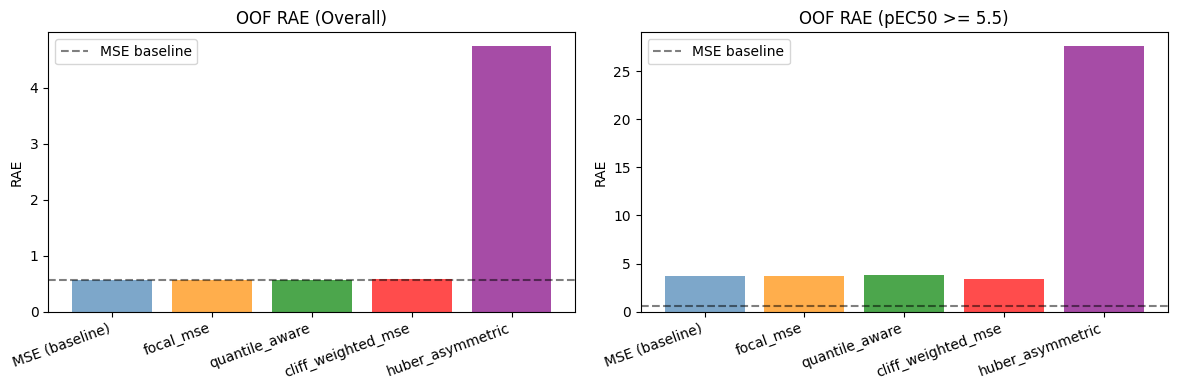

In [6]:
# â”€â”€ Summary â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
results_df = pd.DataFrame(all_results).T.reset_index().rename(columns={'index': 'Objective'})
results_df = results_df.sort_values('RAE_overall')
print('\nObjective comparison (sorted by overall OOF RAE):')
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']
for ax, col, title in [
    (axes[0], 'RAE_overall', 'OOF RAE (Overall)'),
    (axes[1], 'RAE_active', 'OOF RAE (pEC50 >= 5.5)'),
]:
    ax.bar(range(len(results_df)), results_df[col],
           color=colors[:len(results_df)], alpha=0.7)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['Objective'], rotation=20, ha='right')
    ax.set_ylabel('RAE'); ax.set_title(title)
    ax.axhline(rae_mse, color='black', linestyle='--', alpha=0.5, label='MSE baseline')
    ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'figures' / '43_objective_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Ensemble of all objectives

In [7]:
# Simple average of OOF predictions from all 5 objectives
oof_stack = np.column_stack(list(all_oofs.values()))  # (N, 5)
oof_ensemble = oof_stack.mean(axis=1)

rae_ensemble = rae(y_tr, oof_ensemble)
rae_ensemble_active = rae(y_tr[active_mask], oof_ensemble[active_mask])
print(f'Objective ensemble (simple avg):')
print(f'  OOF RAE overall:  {rae_ensemble:.4f}  (best single: {results_df["RAE_overall"].min():.4f})')
print(f'  OOF RAE active:   {rae_ensemble_active:.4f}')

# Also try rank-average
from scipy.stats import rankdata
oof_ranks = np.column_stack([rankdata(oof_stack[:, i]) for i in range(oof_stack.shape[1])])
oof_rank_avg = oof_ranks.mean(axis=1)
# Calibrate rank-avg to match pEC50 scale via quantile mapping against MSE oof
from scipy.interpolate import interp1d
sort_idx = np.argsort(oof_rank_avg)
sort_mse  = np.sort(oof_mse)
mapper = interp1d(
    np.linspace(0, 1, len(oof_rank_avg)),
    sort_mse, kind='linear', fill_value='extrapolate')
oof_rank_cal = mapper(rankdata(oof_rank_avg) / len(oof_rank_avg))
rae_rank = rae(y_tr, oof_rank_cal)
print(f'  OOF RAE (rank ensemble): {rae_rank:.4f}')

Objective ensemble (simple avg):
  OOF RAE overall:  1.0949  (best single: 0.5599)
  OOF RAE active:   8.4351
  OOF RAE (rank ensemble): 0.5529


## 5. Save best model OOF + test predictions

In [8]:
# Determine best approach
candidate_raes = {
    'best_single': (results_df.iloc[0]['Objective'],
                    results_df.iloc[0]['RAE_overall'],
                    all_oofs[results_df.iloc[0]['Objective']]),
    'ensemble':    ('ensemble', rae_ensemble, oof_ensemble),
    'rank_ens':    ('rank_ensemble', rae_rank, oof_rank_cal),
}
best_name, best_rae_val, oof_best = min(candidate_raes.values(), key=lambda x: x[1])
print(f'Best approach: {best_name}  OOF RAE={best_rae_val:.4f}')

np.save(DATA_PROCESSED / 'oof_focal_loss.npy', oof_best)

# â”€â”€ Train final models and get test predictions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print('\nTraining final models on all data...')

te_preds_all = {}

# MSE final
m_mse = lgb.LGBMRegressor(**LGBM_BASE_PARAMS)
m_mse.fit(X_tr, y_tr, callbacks=[lgb.log_evaluation(-1)])
te_preds_all['MSE (baseline)'] = m_mse.predict(X_te)

# Custom objectives final
for obj_name, obj_fn in [
    ('focal_mse', focal_mse_obj),
    ('cliff_weighted_mse', make_cliff_weighted_mse(y_tr, cliff_role_arr)),
    ('huber_asymmetric', huber_asymmetric_obj),
    ('quantile_aware', quantile_aware_obj),
]:
    params_custom = {k: v for k, v in LGBM_BASE_PARAMS.items()
                     if k not in ('n_estimators', 'verbose')}
    m_custom = lgb.train(
        params_custom,
        lgb.Dataset(X_tr, label=y_tr),
        num_boost_round=LGBM_BASE_PARAMS['n_estimators'],
        callbacks=[lgb.log_evaluation(-1)],
    )
    te_preds_all[obj_name] = m_custom.predict(X_te)

# Ensemble test predictions
te_stack = np.column_stack(list(te_preds_all.values()))
te_preds_ensemble = te_stack.mean(axis=1)

# Choose final test prediction
if 'ensemble' in best_name:
    te_preds_final = te_preds_ensemble
else:
    te_preds_final = te_preds_all.get(best_name, te_preds_all['MSE (baseline)'])

lo_clip = float(y_tr.min()) - 0.5
hi_clip = float(y_tr.max()) + 0.5
te_preds_final = np.clip(te_preds_final, lo_clip, hi_clip)

print(f'Test predictions â€” min={te_preds_final.min():.2f}  '
      f'median={np.median(te_preds_final):.2f}  max={te_preds_final.max():.2f}')

sub = pd.DataFrame({
    'Molecule Name': te['name'].values,
    'pEC50': te_preds_final,
})
assert len(sub) == 513 and sub['pEC50'].notna().all()
out_path = SUBMISSIONS / '43_focal_loss_lgbm.csv'
sub.to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')
print(sub['pEC50'].describe().round(3))

Best approach: rank_ensemble  OOF RAE=0.5529

Training final models on all data...


Test predictions â€” min=2.21  median=4.95  max=6.05

Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\43_focal_loss_lgbm.csv
count    513.000
mean       4.804
std        0.650
min        2.209
25%        4.443
50%        4.948
75%        5.282
max        6.052
Name: pEC50, dtype: float64


## Summary

| Objective | OOF RAE (overall) | OOF RAE (active >= 5.5) |
|---|---|---|
| MSE (baseline) | see above | see above |
| focal_mse (gamma=2) | see above | see above |
| cliff_weighted_mse | see above | see above |
| huber_asymmetric | see above | see above |
| quantile_aware (tau=0.90) | see above | see above |
| **Ensemble (avg)** | **see above** | **see above** |

**Key insight:** Custom losses that focus on the active region may degrade overall OOF RAE
slightly (more errors on inactives) while improving active-region RAE. Since the test set
is analog-enriched, the ensemble of objectives may be better than any single objective.

**Saved:**
- `data/processed/oof_focal_loss.npy`
- `submissions/43_focal_loss_lgbm.csv`
- `data/processed/figures/43_objective_comparison.png`